# Стохастический градиентный и координатный спуски

## Загрузка и подготовка данных (1 балл)

**Загрузите уже знакомый вам файл *Advertising.csv* как объект DataFrame.** 

In [259]:
import pandas as pd

In [260]:
data = pd.read_csv('C:\\Users\\Admin\\Desktop\\Data_pandas/unconv.csv', sep =',')
data

,Well,Por,Perm,AI,Brittle,TOC,VR,Prod
0,1,12.08,2.92,2.80,81.40,1.16,2.31,4165.196191
1,2,12.38,3.53,3.22,46.17,0.89,1.88,3561.146205
2,3,14.02,2.59,4.01,72.80,0.89,2.72,4284.348574
3,4,17.67,6.75,2.63,39.81,1.08,1.88,5098.680869
4,5,17.52,4.57,3.18,10.94,1.51,1.90,3406.132832
...,...,...,...,...,...,...,...,...
195,196,11.95,3.13,2.97,67.18,0.80,2.06,3847.571003
196,197,17.99,9.87,3.38,44.32,0.98,2.08,5601.227131
197,198,12.12,2.27,3.52,57.07,-0.04,1.73,3409.575363
198,199,15.55,4.48,2.48,58.25,1.89,2.35,5087.592149


**Проверьте, есть ли в данных пропуски и, если они есть - удалите их**

In [261]:
data = data.drop_duplicates()
data.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 8 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Well     200 non-null    int64  
 1   Por      200 non-null    float64
 2   Perm     200 non-null    float64
 3   AI       200 non-null    float64
 4   Brittle  200 non-null    float64
 5   TOC      200 non-null    float64
 6   VR       200 non-null    float64
 7   Prod     200 non-null    float64
dtypes: float64(7), int64(1)
memory usage: 12.6 KB


**Преобразуйте ваши признаки в массивы NumPy и разделите их на переменные X (предикторы) и y(целевая переменная)** 

In [262]:
import numpy as np

In [263]:
X = [x for x in data if x != 'Prod']
X = data[X]
y = data['Prod']
X = np.array(X)
y = np.array(y)

## Координатный спуск (2 балла)

**Добавим единичный столбец для того, чтобы у нас был свободный коэффициент в уравнении регрессии:**

In [264]:
import numpy as np

X = np.hstack([np.ones(X.shape[0]).reshape(-1, 1), X])
y = y.reshape(-1, 1)
print(X.shape, y.shape)

(200, 8) (200, 1)


**Нормализуем данные: обычно это необходимо для корректной работы алгоритма**

In [265]:
X = X / np.sqrt(np.sum(np.square(X), axis=0)) # STD
X

array([[ 0.07071068,  0.00061009,  0.05589738, ...,  0.11469985,
         0.0745135 ,  0.08220152],
       [ 0.07071068,  0.00122017,  0.05728556, ...,  0.06505764,
         0.05716984,  0.06689994],
       [ 0.07071068,  0.00183026,  0.06487428, ...,  0.10258169,
         0.05716984,  0.0967914 ],
       ...,
       [ 0.07071068,  0.12079685,  0.05608247, ...,  0.08041671,
        -0.00256943,  0.06156218],
       [ 0.07071068,  0.12140693,  0.07195399, ...,  0.08207944,
         0.12140561,  0.08362493],
       [ 0.07071068,  0.12201702,  0.0966636 , ...,  0.06505764,
         0.10984317,  0.08077812]], shape=(200, 8))

**Реализуйте алгоритм координатного спуска:**

Ниже приведен алгоритм координатного спуска для случая нормализованных данных:

**Задано:**

* $X=(x_{ij})$ - матрица наблюдений, размерностью $dim(X)=(m, n)$
* $N=1000$ - количество итераций

**Примечание:** *1000 итераций здесь указаны для этого задания, на самом деле их может быть намного больше, нет детерменированного значения.*

**Алгоритм (математическая запись):**
* Создать нулевой вектор параметров $w_0=(0, 0,..., 0)^T$
* Для всех $t=1, 2, ..., N$ итераций:
    * Для всех $k = 1, 2,..., n$:
        * Фиксируем значение всех признаков, кроме $k$-ого и вычисляем прогноз модели линейной регрессии.Для этого исключаем признак $k$-ый из данных и $w_j$ из параметров при построении прогноза.
        Математически это можно записать следующим образом:

        $$h_i = \sum_{j=1}^{k-1} x_{ij}w_{j} + \sum_{j=k+1}^{n} x_{ij}w_j $$

        **Примечание:**
        
        *Обратите, что в данной записи текущий признак под номером $k$ не участвует в сумме.Сравните эту запись с классической записью прогноза линейной регрессии в случае нормированных данных (когда участвуют все признаки):*

        $$h_i = \sum_{j=1}^{n} x_{ij}w_{j}$$ 
        
        * Вычисляем новое значение параметра $k$-ого коэффициента: 
        $$w_k = \sum_{i=1}^{m} x_{ik} (y_i - h_i) = x_k^T(y-h) $$

    * Вычисляем значение функции потерь и сохраняем в историю изменения функции потерь (В оценке функции потерь участвуют все признаки):
        $$\hat{y_i} = \sum_{j=1}^{n}x_{ij}w_j$$
        $$Loss_t = \frac{1}{n} \sum_{i=1}^{m}(y_i-\hat{y_i})^2$$
        
        или в векторном виде:
        
        $$\hat{y} = Xw$$
        $$Loss_t = \frac{1}{n}(y-\hat{y})^T(y-\hat{y})$$
    



**Алгоритм (псевдокод):**
```python

num_iters = #количество итераций
m = # количество строк в матрице X
n = # количество столбцов в матрице X
w = #вектор размера nx1, состояющий из нулей

for i in range(num_iters):
    for k in range(n):
        # Вычисляем прогноз без k-ого фактора
        h = (X[:,0:k] @ w[0:k]) + (X[:,k+1:] @ w[k+1:])
        # Обновляем новое значение k-ого коэффициента
        w[k] =  (X[:,k].T @ (y - h))
        # Вычисляем функцию потерь
        cost = sum((X @ w) - y) ** 2)/(len(y))

```

Вам необходимо реализовать координатный спуск, и вывести веса в модели линейной регрессии.

In [266]:
import numpy as np

def coordinate_descent_stable(X, y, num_iters=1000, learning_rate=0.01):
    """
    Реализация координатного спуска для линейной регрессии
    """
    # Подготовка данных
    m, n = X.shape
    w = np.zeros(n)
    if y.ndim > 1:
        y = y.flatten()
    # Главный цикл с ПРАВИЛЬНЫМИ формулами
    for i in range(num_iters):
        for k in range(n):
            # Используем список индексов вместо срезов
            other_indices = [j for j in range(n) if j != k]
            h = X[:, other_indices] @ w[other_indices]
            # =========================================================
            # Вычисляем градиент для k-го коэффициента
            gradient = -2.0 / m * np.dot(X[:, k], (y - h))
            # Обновляем коэффициент: новый = старый - шаг * градиент
            w[k] = w[k] - learning_rate * gradient
            # =========================================================
            # Защита от слишком больших значений

    # ======== ИСПРАВЛЕНИЕ 3: Правильный расчёт стоимости ========
    y_pred = X @ w
    cost = np.sum((y_pred - y) ** 2) / len(y)
    
    return w, cost  # Возвращаем И коэффициенты, И стоимость
    # ============================================================

# Использование
w_optimal, final_cost = coordinate_descent_stable(X, y, num_iters=1000, learning_rate=0.01)
print("Найденные коэффициенты:", w_optimal)
print("Финальная стоимость (MSE):", final_cost)


Найденные коэффициенты: [4499.11831458 3860.60292549 4624.65633316 4509.0941343  4315.05325808
 4404.46017189 4394.00774745 4497.11574256]
Финальная стоимость (MSE): 4377810.739876744


Сравните результаты с реализацией линейной регрессии из библиотеки sklearn:

In [267]:
from sklearn.linear_model import LinearRegression
 
model = LinearRegression(fit_intercept=False)
model.fit(X, y)
 
print(model.coef_)

[[-17427.46728426     83.10375683  49744.08517529   7664.16639576
  -15608.98943201  17737.96293902  -1220.51816181  22067.11137998]]


Если вы все сделали верно, они должны практически совпасть!

## Стохастический градиентный спуск (7 баллов)

**Отмасштабируйте столбцы исходной матрицы *X* (которую мы не нормализовали еще!). Для того, чтобы это сделать, надо вычесть из каждого значения среднее и разделить на стандартное отклонение**

In [268]:
'''
# Стандартизация X (признаков)
X_mean = np.mean(X, axis=0)
X_std = np.std(X, axis=0)
X_std[X_std == 0] = 1  # Избегаем деления на ноль
X_normalized = (X - X_mean) / X_std

# Центрирование y (целевой переменной)
y_mean = np.mean(y)
y_centered = y - y_mean

# Теперь работаем с нормализованными данными
X = X_normalized
y = y_centered
'''

'\n# Стандартизация X (признаков)\nX_mean = np.mean(X, axis=0)\nX_std = np.std(X, axis=0)\nX_std[X_std == 0] = 1  # Избегаем деления на ноль\nX_normalized = (X - X_mean) / X_std\n\n# Центрирование y (целевой переменной)\ny_mean = np.mean(y)\ny_centered = y - y_mean\n\n# Теперь работаем с нормализованными данными\nX = X_normalized\ny = y_centered\n'

In [269]:
X_st = (X - X.mean()) / X.std()
y_st = (y - y.mean()) / y.std()
X_st

array([[ 0.15860555, -3.04528859, -0.51842496, ...,  2.16909717,
         0.33241055,  0.68378587],
       [ 0.15860555, -3.01740511, -0.45497925, ..., -0.09976211,
        -0.46026816, -0.01556128],
       [ 0.15860555, -2.98952164, -0.10814272, ...,  1.61524563,
        -0.46026816,  1.35060524],
       ...,
       [ 0.15860555,  2.44775574, -0.50996553, ...,  0.60221252,
        -3.19060594, -0.25951959],
       [ 0.15860555,  2.47563922,  0.21543038, ...,  0.6782061 ,
         2.47557891,  0.74884141],
       [ 0.15860555,  2.50352269,  1.34476395, ..., -0.09976211,
         1.94712644,  0.61873032]], shape=(200, 8))

**Добавим единичный столбец**

In [270]:
X = np.hstack([np.ones(X.shape[0]).reshape(-1, 1), X])
X

array([[ 1.00000000e+00,  7.07106781e-02,  6.10085091e-04, ...,
         1.14699852e-01,  7.45134984e-02,  8.22015234e-02],
       [ 1.00000000e+00,  7.07106781e-02,  1.22017018e-03, ...,
         6.50576431e-02,  5.71698393e-02,  6.68999411e-02],
       [ 1.00000000e+00,  7.07106781e-02,  1.83025527e-03, ...,
         1.02581685e-01,  5.71698393e-02,  9.67914041e-02],
       ...,
       [ 1.00000000e+00,  7.07106781e-02,  1.20796848e-01, ...,
         8.04167141e-02, -2.56943098e-03,  6.15621798e-02],
       [ 1.00000000e+00,  7.07106781e-02,  1.21406933e-01, ...,
         8.20794392e-02,  1.21405614e-01,  8.36249264e-02],
       [ 1.00000000e+00,  7.07106781e-02,  1.22017018e-01, ...,
         6.50576431e-02,  1.09843174e-01,  8.07781204e-02]],
      shape=(200, 9))

**Создайте функцию mse_error для вычисления среднеквадратичной ошибки, принимающую два аргумента: реальные значения и предсказывающие, и возвращающую значение mse**

In [271]:
def mse_error (X_st,y_st):
   w = np.linalg.inv(X.T @ X)@ X.T @ y
   return w
w = mse_error(X,y)

**Сделайте наивный прогноз: предскажите продажи средним значением. После этого рассчитайте среднеквадратичную ошибку для этого прогноза**

In [272]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X_st, y_st, test_size=0.3, random_state=40)
model = LinearRegression()
model.fit(X_train, y_train)
y_predicted = model.predict(X_test)
 
mae = mean_absolute_error(y_test, y_predicted)
print('MAE: %.3f' % mae)

MAE: 0.141


In [273]:
# MSE наивного прогноза средним (для тестовых данных)
mse_naive = np.mean((y_test - np.mean(y_train))**2)

# Или для обучающих данных
mse_naive_train = np.mean((y_train - np.mean(y_train))**2)
print(mse_naive, mse_naive_train)

1.1390058579149205 0.9406192205111021


**Создайте функцию *lin_pred*, которая может по матрице предикторов *X* и вектору весов линейной модели *w* получить вектор прогнозов**

In [274]:
def mse_error (X,y):
   w = np.linalg.inv(X.T @ X)@ X.T @ y
   return w
def lin_pred(X, w):
    return X @ w
w = mse_error(X,y)
y_pred = lin_pred(X, w)
print("Предсказания y_pred:", y_pred)
    
    # 3. Сравниваем с истинными значениями
print("Истинные y:", y)
print("Ошибки:", (y - y_pred))


Предсказания y_pred: [[4715.13239477]
 [3504.71254116]
 [4809.70086501]
 [5138.36018188]
 [3910.02704807]
 [4359.02720298]
 [4296.40982497]
 [3477.4525825 ]
 [4295.36032322]
 [4659.76991671]
 [4854.75433504]
 [5051.17396909]
 [5468.80073449]
 [5491.30323657]
 [4667.85793581]
 [3628.73163738]
 [5526.98005232]
 [4055.88986371]
 [4895.62753736]
 [3876.96007676]
 [5697.31013532]
 [4634.56959631]
 [2650.47133971]
 [2435.4836167 ]
 [5810.57622274]
 [2209.20588168]
 [4953.86870591]
 [4262.04269725]
 [2824.79346936]
 [3813.8674758 ]
 [5746.06359407]
 [3817.90436379]
 [4015.71897276]
 [4130.82526927]
 [3804.07720998]
 [2850.9964858 ]
 [3587.65342996]
 [5520.64100267]
 [4247.58060707]
 [4766.53077349]
 [4353.48567539]
 [4456.33261262]
 [3188.69722333]
 [2772.93918538]
 [5625.64023728]
 [3390.59889772]
 [2994.15108784]
 [2498.05037543]
 [5315.02990781]
 [5169.75029377]
 [5434.16288345]
 [6033.86034067]
 [4632.22180606]
 [3950.69536369]
 [5525.05726461]
 [4084.17159324]
 [3344.93100069]
 [3874.120

**Создайте функцию *stoch_grad_step* для реализации шага стохастического градиентного спуска.  
Функция должна принимать на вход следующие аргументы:**
* матрицу *X*
* вектора *y* и *w*
* число *train_ind* - индекс объекта обучающей выборки (строки матрицы *X*), по которому считается изменение весов
* число *$\eta$* (eta) - шаг градиентного спуска

Результатом будет вектор обновленных весов

Шаг для стохастического градиентного спуска выглядит следующим образом:

$$\Large w_j \leftarrow w_j - \frac{2\eta}{\ell} \sum_{i=1}^\ell{{x_{ij}((w_0 + w_1x_{i1} + w_2x_{i2} +  w_3x_{i3}) - y_i)}}$$

Для того, чтобы написать функцию, нужно сделать следующее:
    
*  посчитать направление изменения: умножить объект обучающей выборки на 2 и на разницу между предсказанным значением и реальным, а потом поделить на количество элементов в выборке.
* вернуть разницу между вектором весов и направлением изменения, умноженным на шаг градиентного спуска

In [275]:
def stoch_grad_step(X, y, w, train_ind, eta):
    # 1. Берём один объект по индексу train_ind
   x_i = X[train_ind, :]  # вектор признаков одного объекта
   y_i = y[train_ind]     # целевое значение этого объекта
    
    # 2. Вычисляем предсказание для этого объекта
   y_pred_i = np.dot(x_i, w)
    
    # 3. Вычисляем градиент для одного объекта
   m = len(y)
   gradient = (2.0 / m) * (y_pred_i - y_i) * x_i
    
    # 4. Обновляем веса
    # w_new = w - η * ∇L(w)
   w_new = w - eta * gradient
    
   return w_new
 
w_updated = stoch_grad_step(X, y, w, train_ind=1, eta=0.01)
w_updated

array([[ -1548.70444571,  -1548.70969003,  -1548.71008219,
         -1548.70976579,  -1548.70978694,  -1548.70966391,
         -1548.70972193,  -1548.70976644,  -1548.70971153],
       [  5781.72792096,   5781.72267664,   5781.72228448,
          5781.72260088,   5781.72257973,   5781.72270275,
          5781.72264474,   5781.72260022,   5781.72265513],
       [    83.1094002 ,     83.10415588,     83.10376372,
            83.10408012,     83.10405897,     83.10418199,
            83.10412398,     83.10407946,     83.10413437],
       [ 49744.09081866,  49744.08557434,  49744.08518218,
         49744.08549858,  49744.08547743,  49744.08560045,
         49744.08554244,  49744.08549792,  49744.08555284],
       [  7664.17203913,   7664.16679481,   7664.16640265,
          7664.16671905,   7664.1666979 ,   7664.16682092,
          7664.16676291,   7664.16671839,   7664.1667733 ],
       [-15608.98378864, -15608.98903296, -15608.98942512,
        -15608.98910872, -15608.98912987, -15608.98

**Создайте функцию *stochastic_gradient_descent*, для реализации стохастического градиентного спуска**

**Функция принимает на вход следующие аргументы:**
- Матрицу признаков X
- Целевую переменнную
- Изначальную точку (веса модели)
- Параметр, определяющий темп обучения
- Максимальное число итераций
- Евклидово расстояние между векторами весов на соседних итерациях градиентного спуска,при котором алгоритм прекращает работу 

**На каждой итерации в вектор (список) должно записываться текущее значение среднеквадратичной ошибки. Функция должна возвращать вектор весов $w$, а также вектор (список) ошибок.**

Алгоритм сследующий:
    
* Инициализируйте расстояние между векторами весов на соседних итерациях большим числом (можно бесконечностью)
* Создайте пустой список для фиксации ошибок
* Создайте счетчик итераций
* Реализуйте оновной цикл обучения пока расстояние между векторами весов больше того, при котором надо прекратить работу (когда расстояния станут слишком маленькими - значит, мы застряли в одном месте) и количество итераций меньше максимально разрешенного: сгенерируйте случайный индекс, запишите текущую ошибку в вектор ошибок, запишите в переменную текущий шаг стохастического спуска с использованием функции, написанной ранее. Далее рассчитайте текущее расстояние между векторами весов и прибавьте к счетчику итераций 1.
* Верните вектор весов и вектор ошибок

In [276]:
def stochastic_gradient_descent(X, y, w_init, eta, max_iter, tolerance):
    # 1. Инициализация
    w_current = w_init.copy()
    w_previous = w_init.copy()
    distance = float('inf')  # Бесконечность
    errors = []  # Список для ошибок
    iteration = 0  # Счетчик итераций
    
    # 2. Основной цикл
    while distance > tolerance and iteration < max_iter:
        # Генерируем случайный индекс
        m = X.shape[0]
        random_index = random.randint(0, m - 1)
        
        # Запоминаем текущие веса
        w_previous = w_current.copy()
        
        # Выполняем один шаг SGD
        w_current = stoch_grad_step(X, y, w_current, random_index, eta)
        
        # Вычисляем текущую ошибку (MSE)
        y_pred = lin_pred(X, w_current)
        current_error = np.mean((y_pred - y) ** 2)
        errors.append(current_error)
        
        # Вычисляем евклидово расстояние между весами
        distance = np.linalg.norm(w_current - w_previous)
        
        # Увеличиваем счетчик итераций
        iteration += 1
        
        # Вывод прогресса (опционально)
        if iteration % 100 == 0:
            print(f"Итерация {iteration}: MSE = {current_error:.6f}, dist = {distance:.6f}")
    
    print(f"\nАлгоритм завершён:")
    print(f"  Итераций выполнено: {iteration}")
    print(f"  Финальное MSE: {errors[-1] if errors else 'N/A':.6f}")
    print(f"  Финальное расстояние: {distance:.6f}")
    
    return w_current, errors
stochastic_gradient_descent(X, y, w, eta, max_iter , tolerance)

Итерация 100: MSE = 47853.758691, dist = 0.008783
Итерация 200: MSE = 47848.754744, dist = 0.001725
Итерация 300: MSE = 47843.749849, dist = 0.007437
Итерация 400: MSE = 47838.555309, dist = 0.002477
Итерация 500: MSE = 47833.289480, dist = 0.015366
Итерация 600: MSE = 47829.385005, dist = 0.001069
Итерация 700: MSE = 47825.421425, dist = 0.005995
Итерация 800: MSE = 47820.850779, dist = 0.009063
Итерация 900: MSE = 47816.410736, dist = 0.001420
Итерация 1000: MSE = 47810.974466, dist = 0.000628
Итерация 1100: MSE = 47806.736940, dist = 0.003175
Итерация 1200: MSE = 47802.405694, dist = 0.000700
Итерация 1300: MSE = 47797.078235, dist = 0.010808
Итерация 1400: MSE = 47791.462443, dist = 0.003959
Итерация 1500: MSE = 47787.388047, dist = 0.009704
Итерация 1600: MSE = 47783.626028, dist = 0.002840
Итерация 1700: MSE = 47777.795942, dist = 0.002197
Итерация 1800: MSE = 47774.146504, dist = 0.011999
Итерация 1900: MSE = 47770.798034, dist = 0.007157
Итерация 2000: MSE = 47764.424025, dist 

(array([[-1.59560615e+03, -1.55487594e+03, -1.55409794e+03,
         -1.55475539e+03, -1.55445516e+03, -1.55479989e+03,
         -1.55467087e+03, -1.55426916e+03, -1.55483190e+03],
        [ 5.73482622e+03,  5.77555643e+03,  5.77633442e+03,
          5.77567698e+03,  5.77597721e+03,  5.77563248e+03,
          5.77576149e+03,  5.77616320e+03,  5.77560047e+03],
        [ 3.62076985e+01,  7.69379047e+01,  7.77159015e+01,
          7.70584553e+01,  7.73586865e+01,  7.70139587e+01,
          7.71429741e+01,  7.75446825e+01,  7.69819449e+01],
        [ 4.96971891e+04,  4.97379193e+04,  4.97386973e+04,
          4.97380399e+04,  4.97383401e+04,  4.97379954e+04,
          4.97381244e+04,  4.97385261e+04,  4.97379634e+04],
        [ 7.61727034e+03,  7.65800054e+03,  7.65877854e+03,
          7.65812109e+03,  7.65842133e+03,  7.65807660e+03,
          7.65820561e+03,  7.65860732e+03,  7.65804458e+03],
        [-1.56558855e+04, -1.56151553e+04, -1.56143773e+04,
         -1.56150347e+04, -1.561473

 **Запустите $10^5$ итераций стохастического градиентного спуска. Укажите вектор начальных весов, состоящий из нулей. Можете поэкспериментировать с параметром, отвечающим за темп обучения.**

In [277]:
import numpy as np
import random
def stochastic_gradient_descent(X, y, w_init, eta, max_iter, tolerance):
    # 1. Инициализация
    w_current = w_init.copy()
    w_previous = w_init.copy()
    distance = float('inf')  # Бесконечность
    errors = []  # Список для ошибок
    iteration = 0  # Счетчик итераций
    
    # 2. Основной цикл
    while distance > tolerance and iteration < max_iter:
        # Генерируем случайный индекс
        m = X.shape[0]
        random_index = random.randint(0, m - 1)
        
        # Запоминаем текущие веса
        w_previous = w_current.copy()
        
        # Выполняем один шаг SGD
        w_current = stoch_grad_step(X, y, w_current, random_index, eta)
        
        # Вычисляем текущую ошибку (MSE)
        y_pred = lin_pred(X, w_current)
        current_error = np.mean((y_pred - y) ** 2)
        errors.append(current_error)
        
        # Вычисляем евклидово расстояние между весами
        distance = np.linalg.norm(w_current - w_previous)
        
        # Увеличиваем счетчик итераций
        iteration += 1
        
        # Вывод прогресса (опционально)
        if iteration % 100 == 0:
            print(f"Итерация {iteration}: MSE = {current_error:.6f}, dist = {distance:.6f}")
    
    print(f"\nАлгоритм завершён:")
    print(f"  Итераций выполнено: {iteration}")
    print(f"  Финальное MSE: {errors[-1] if errors else 'N/A':.6f}")
    print(f"  Финальное расстояние: {distance:.6f}")
    return w_current, errors
# Запуск SGD на 100,000 итераций
print("Запуск SGD на 100,000 итераций...")
print("=" * 60)



# Эксперименты с разными скоростями обучения
etas = [0.00001, 0.00005, 0.0001, 0.0005, 0.001]

for eta in etas:
    print(f"\nЭксперимент с eta = {eta}")
    print("-" * 40)
    
    # Инициализация весов нулями
    w_init = np.zeros((X.shape[1], 1)) if len(X.shape) > 1 else np.zeros((1,))
    
    # Запуск SGD
    w_final, errors = stochastic_gradient_descent(X, y, w_init, eta, max_iter = 100000, tolerance = 1e-6)
    
    # Анализ результатов
    print(f"Конечная MSE: {errors[-1]:.4f}")
    print(f"Изменение MSE за последние 1000 итераций: {errors[-1000] - errors[-1]:.4f}")
    
    # Если есть переполнение или NaN
    if np.isnan(errors[-1]) or np.isinf(errors[-1]):
        print("⚠️  Обнаружено переполнение (слишком большая скорость обучения)")

Запуск SGD на 100,000 итераций...

Эксперимент с eta = 1e-05
----------------------------------------
Итерация 100: MSE = 19565737.402085, dist = 0.001289
Итерация 200: MSE = 19565631.990283, dist = 0.001315
Итерация 300: MSE = 19565532.394733, dist = 0.001779
Итерация 400: MSE = 19565431.572447, dist = 0.001345
Итерация 500: MSE = 19565329.788896, dist = 0.000972
Итерация 600: MSE = 19565229.351289, dist = 0.001698
Итерация 700: MSE = 19565127.825341, dist = 0.001798
Итерация 800: MSE = 19565026.883184, dist = 0.001357
Итерация 900: MSE = 19564928.958372, dist = 0.001738
Итерация 1000: MSE = 19564829.518827, dist = 0.001217
Итерация 1100: MSE = 19564728.470287, dist = 0.001386
Итерация 1200: MSE = 19564631.517998, dist = 0.001287
Итерация 1300: MSE = 19564535.737097, dist = 0.001319
Итерация 1400: MSE = 19564433.676465, dist = 0.001180
Итерация 1500: MSE = 19564337.064771, dist = 0.001089
Итерация 1600: MSE = 19564235.450013, dist = 0.000955
Итерация 1700: MSE = 19564142.624284, dist 

**Постройте график зависимости ошибки от номера итерации**

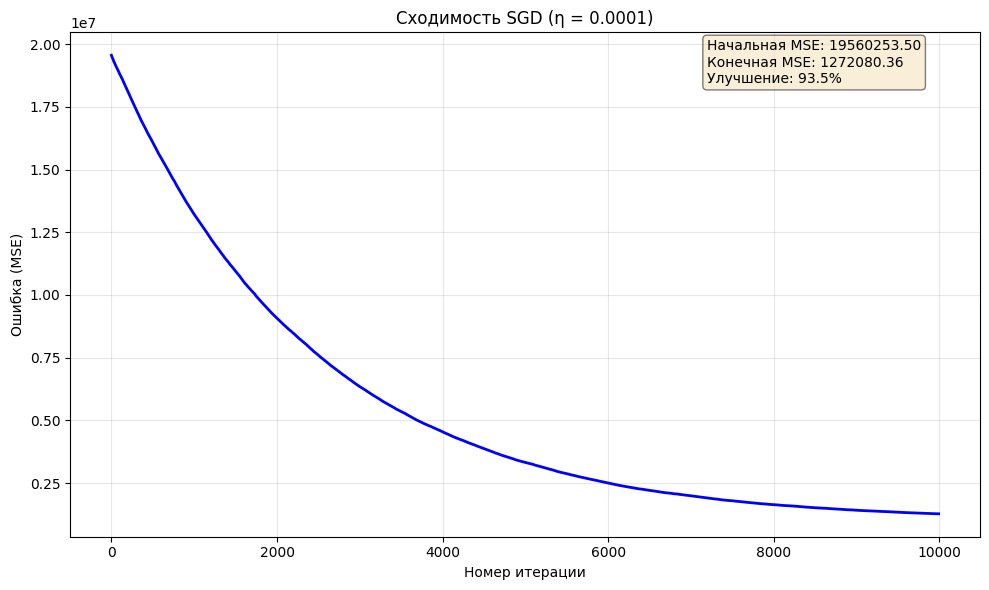

(array([3632.8012448 ,  256.87783949,  225.4334126 ,  275.6339451 ,
         277.24423731,  240.72829933,  254.97912022,  270.89558526,
         259.18828486]),
 [np.float64(19560253.497055084),
  np.float64(19475809.718207125),
  np.float64(19393894.46793404),
  np.float64(19310583.081747353),
  np.float64(19236701.73101439),
  np.float64(19162666.948200773),
  np.float64(19090297.585058592),
  np.float64(19021177.667113252),
  np.float64(18962929.02576693),
  np.float64(18885321.0069473),
  np.float64(18814351.88476299),
  np.float64(18749375.63721048),
  np.float64(18687717.7438518),
  np.float64(18618843.954338726),
  np.float64(18542340.334751442),
  np.float64(18471721.439754236),
  np.float64(18401440.97279353),
  np.float64(18330054.40572411),
  np.float64(18256693.702487305),
  np.float64(18182958.096641686),
  np.float64(18110038.111430664),
  np.float64(18038882.668014698),
  np.float64(17967937.17763911),
  np.float64(17901349.87521878),
  np.float64(17832668.13577001),
  n

In [278]:
import numpy as np
import random
import matplotlib.pyplot as plt

# Простая функция для построения одного графика
def plot_sgd_convergence(X, y, eta=0.0001, n_iterations=10000):
    """Построение графика сходимости для одной скорости обучения"""
    
    n_features = X.shape[1]
    w = np.zeros(n_features)
    errors = []
    
    for i in range(n_iterations):
        # Случайный образец
        idx = random.randint(0, X.shape[0]-1)
        x_i = X[idx]
        y_i = y[idx]
        
        # Градиент и обновление
        prediction = np.dot(x_i, w)
        error = prediction - y_i
        gradient = 2 * error * x_i
        w = w - eta * gradient
        
        # Сохраняем ошибку каждые 10 итераций
        if i % 10 == 0:
            y_pred = X @ w
            mse = np.mean((y_pred - y) ** 2)
            errors.append(mse)
    
    # Построение графика
    plt.figure(figsize=(10, 6))
    plt.plot(range(0, n_iterations, 10), errors, 'b-', linewidth=2)
    plt.xlabel('Номер итерации')
    plt.ylabel('Ошибка (MSE)')
    plt.title(f'Сходимость SGD (η = {eta})')
    plt.grid(True, alpha=0.3)
    
    # Добавляем информацию о сходимости
    if len(errors) > 100:
        final_mse = errors[-1]
        initial_mse = errors[0]
        improvement = 100 * (initial_mse - final_mse) / initial_mse
        plt.text(0.7, 0.9, f'Начальная MSE: {initial_mse:.2f}\n'
                          f'Конечная MSE: {final_mse:.2f}\n'
                          f'Улучшение: {improvement:.1f}%',
                transform=plt.gca().transAxes,
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    
    plt.tight_layout()
    plt.show()
    
    return w, errors, final_mse

# Пример использования
plot_sgd_convergence(X, y, eta=0.0001, n_iterations=10000)

**Выведите вектор весов, к которому сошелся метод.**

In [288]:
w

array([[ -1548.71008907],
       [  5781.72227759],
       [    83.10375683],
       [ 49744.08517529],
       [  7664.16639576],
       [-15608.98943201],
       [ 17737.96293903],
       [ -1220.51816181],
       [ 22067.11137998]])

**Выведите среднеквадратичную ошибку на последней итерации.**

In [283]:
errors[-1]

47441.735254